In [6]:
# Importing necessary libraries
import pandas as pd  # For data manipulation and analysis
import matplotlib.pyplot as plt  # For creating visualizations
import numpy as np  # For numerical computations
import seaborn as sns  # For advanced statistical data visualization

# Preprocessing libraries
from sklearn.preprocessing import LabelEncoder, StandardScaler  # For encoding labels and scaling features
from sklearn.preprocessing import RobustScaler  # Another scaler for handling outliers

# Metrics for model evaluation
from sklearn.metrics import confusion_matrix  # To compute the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay  # To visualize the confusion matrix
from sklearn.metrics import accuracy_score  # To calculate accuracy
from sklearn.metrics import f1_score  # To calculate the F1 score

# Statistical library
from scipy.stats import norm  # For statistical functions like probability distribution

# Splitting data and optimizing models
from sklearn.model_selection import train_test_split  # To split the dataset into training and testing sets
from sklearn.model_selection import GridSearchCV  # For hyperparameter tuning using grid search

# Classification models
from sklearn.ensemble import RandomForestClassifier  # Random Forest Classifier
from catboost import CatBoostClassifier  # CatBoost Classifier, optimized for categorical features
from sklearn.neighbors import KNeighborsClassifier  # K-Nearest Neighbors Classifier
import xgboost as xgb  # Extreme Gradient Boosting Classifier


In [7]:
df = pd.read_csv('dataset_traffic_accident_prediction1.csv')
df

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
0,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,NaN,Wet,Car,51.0,48.0,Artificial Light,0.0
1,Clear,Rural Road,Night,NaN,120.0,3.0,0.0,Moderate,Wet,Truck,49.0,43.0,Artificial Light,0.0
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0.0
4,Rainy,Highway,Morning,1.0,195.0,11.0,0.0,Low,Dry,Car,62.0,55.0,Artificial Light,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,Clear,Highway,Night,2.0,30.0,4.0,0.0,Low,Dry,Car,23.0,15.0,Daylight,0.0
836,Rainy,Rural Road,Evening,2.0,60.0,4.0,0.0,Low,Dry,Motorcycle,52.0,46.0,Daylight,1.0
837,Foggy,Highway,Evening,NaN,30.0,4.0,1.0,High,Dry,Car,NaN,34.0,Artificial Light,NaN
838,Foggy,Highway,Afternoon,2.0,60.0,3.0,0.0,Low,Dry,Car,25.0,19.0,Artificial Light,0.0


In [8]:
df.describe()


,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Driver_Age,Driver_Experience,Accident
count,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000
mean,1.001253,71.050125,3.286967,0.160401,43.259398,38.981203,0.299499
std,0.784894,32.052458,2.017267,0.367208,15.129856,15.273201,0.458326
min,0.000000,30.000000,1.000000,0.000000,18.000000,9.000000,0.000000
25%,0.000000,50.000000,2.000000,0.000000,30.000000,26.000000,0.000000
50%,1.000000,60.000000,3.000000,0.000000,43.000000,39.000000,0.000000
75%,2.000000,80.000000,4.000000,0.000000,56.000000,52.750000,1.000000
max,2.000000,213.000000,14.000000,1.000000,69.000000,69.000000,1.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Weather               798 non-null    object 
 1   Road_Type             798 non-null    object 
 2   Time_of_Day           798 non-null    object 
 3   Traffic_Density       798 non-null    float64
 4   Speed_Limit           798 non-null    float64
 5   Number_of_Vehicles    798 non-null    float64
 6   Driver_Alcohol        798 non-null    float64
 7   Accident_Severity     798 non-null    object 
 8   Road_Condition        798 non-null    object 
 9   Vehicle_Type          798 non-null    object 
 10  Driver_Age            798 non-null    float64
 11  Driver_Experience     798 non-null    float64
 12  Road_Light_Condition  798 non-null    object 
 13  Accident              798 non-null    float64
dtypes: float64(7), object(7)
memory usage: 92.0+ KB


In [10]:
df.isnull().sum()

Weather                 42
Road_Type               42
Time_of_Day             42
Traffic_Density         42
Speed_Limit             42
Number_of_Vehicles      42
Driver_Alcohol          42
Accident_Severity       42
Road_Condition          42
Vehicle_Type            42
Driver_Age              42
Driver_Experience       42
Road_Light_Condition    42
Accident                42
dtype: int64

Traffic_Density - Mean: 1.0012531328320802, Median: 1.0


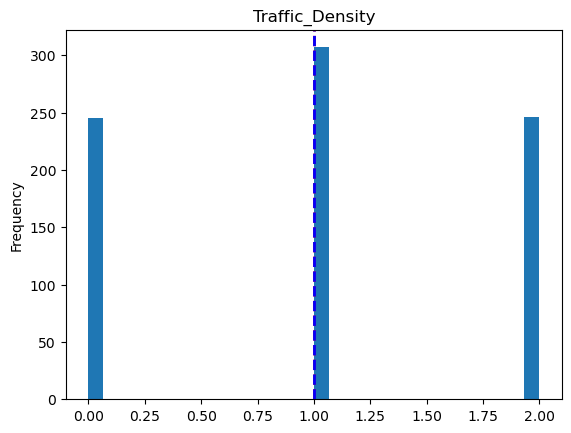

Speed_Limit - Mean: 71.0501253132832, Median: 60.0


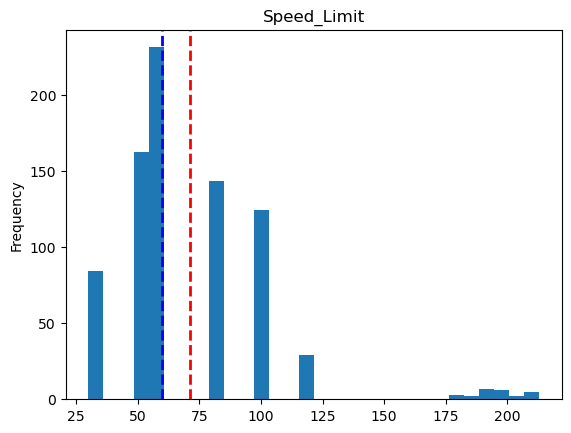

Number_of_Vehicles - Mean: 3.2869674185463658, Median: 3.0


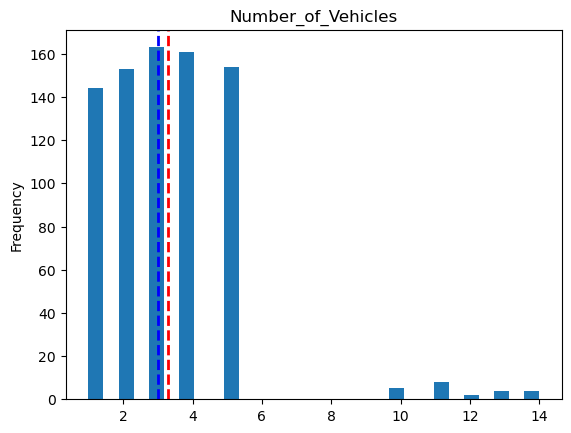

Driver_Alcohol - Mean: 0.16040100250626566, Median: 0.0


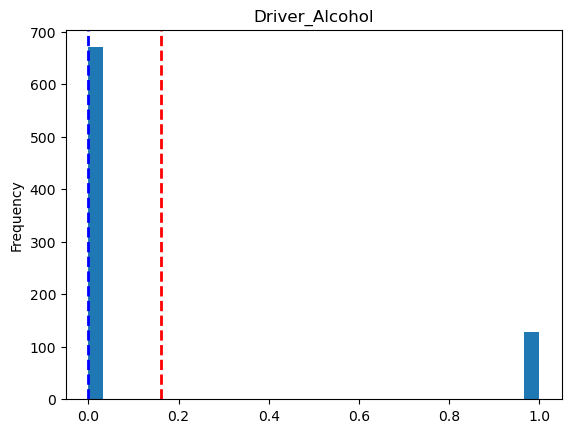

Driver_Age - Mean: 43.2593984962406, Median: 43.0


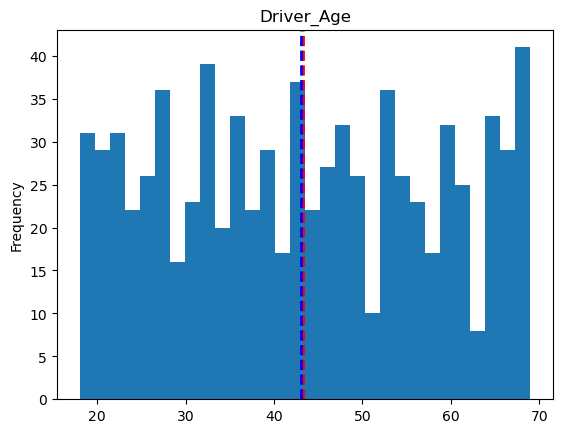

Driver_Experience - Mean: 38.9812030075188, Median: 39.0


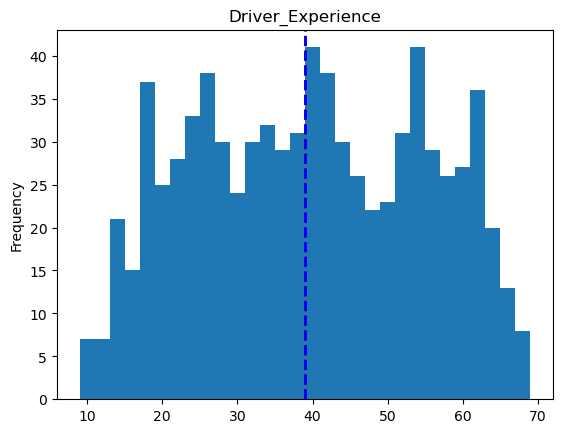

Accident - Mean: 0.29949874686716793, Median: 0.0


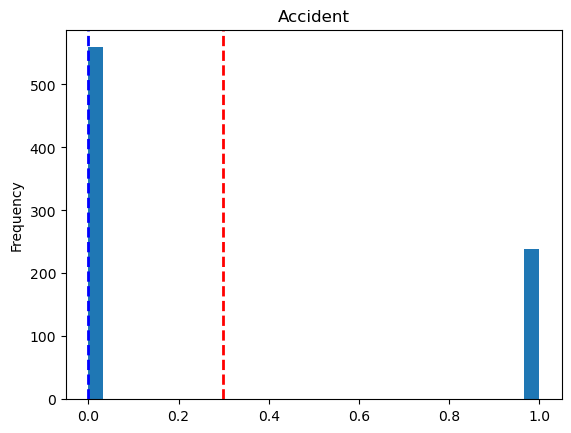

In [11]:
# List of columns that contain missing values or need analysis
columns_with_missing = ['Traffic_Density', 'Speed_Limit', 'Number_of_Vehicles', 'Driver_Alcohol',
                        'Driver_Age', 'Driver_Experience', 'Accident']

# Looping through each column in the list to calculate statistics and visualize data
for i in columns_with_missing:
    # Print mean and median values of the column
    print(f"{i} - Mean: {df[i].mean()}, Median: {df[i].median()}")
    
    # Plotting a histogram to visualize the data distribution of the column
    df[i].plot(kind='hist', bins=30, title=i)  # Histogram with 30 bins
    plt.axvline(df[i].mean(), color='red', linestyle='dashed', linewidth=2)  # Vertical line for mean
    plt.axvline(df[i].median(), color='blue', linestyle='dashed', linewidth=2)  # Vertical line for median
    plt.show()  # Display the plot


In [12]:
# Filling missing values in the 'Traffic_Density' column with the median value of the column
df['Traffic_Density'].fillna(df['Traffic_Density'].median(), inplace=True)

# Filling missing values in the 'Speed_Limit' column with the median value of the column
df['Speed_Limit'].fillna(df['Speed_Limit'].median(), inplace=True)

# Filling missing values in the 'Number_of_Vehicles' column with the median value of the column
df['Number_of_Vehicles'].fillna(df['Number_of_Vehicles'].median(), inplace=True)

# Filling missing values in the 'Driver_Alcohol' column with the median value of the column
df['Driver_Alcohol'].fillna(df['Driver_Alcohol'].median(), inplace=True)

# Filling missing values in the 'Driver_Age' column with the median value of the column
df['Driver_Age'].fillna(df['Driver_Age'].median(), inplace=True)

# Filling missing values in the 'Driver_Experience' column with the median value of the column
df['Driver_Experience'].fillna(df['Driver_Experience'].median(), inplace=True)

# Filling missing values in the 'Accident' column with the median value of the column
df['Accident'].fillna(df['Accident'].median(), inplace=True)


In [13]:
# Identifying columns with missing values
# `df.isnull().sum()` calculates the number of missing values in each column
# `df.columns[df.isnull().sum() > 0]` filters columns where the count of missing values is greater than 0
columns_miss = df.columns[df.isnull().sum() > 0]

# Displaying structural information (like data types and non-null counts) of columns with missing values
# `info()` provides a summary of the DataFrame, including data type and missing/non-missing counts
df[columns_miss].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Weather               798 non-null    object
 1   Road_Type             798 non-null    object
 2   Time_of_Day           798 non-null    object
 3   Accident_Severity     798 non-null    object
 4   Road_Condition        798 non-null    object
 5   Vehicle_Type          798 non-null    object
 6   Road_Light_Condition  798 non-null    object
dtypes: object(7)
memory usage: 46.1+ KB


In [14]:
# Filling missing values in the 'Weather' column with its mode (most frequent value)
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])

# Filling missing values in the 'Road_Type' column with its mode (most frequent value)
df['Road_Type'] = df['Road_Type'].fillna(df['Road_Type'].mode()[0])

# Filling missing values in the 'Time_of_Day' column with its mode (most frequent value)
df['Time_of_Day'] = df['Time_of_Day'].fillna(df['Time_of_Day'].mode()[0])

# Filling missing values in the 'Accident_Severity' column with its mode (most frequent value)
df['Accident_Severity'] = df['Accident_Severity'].fillna(df['Accident_Severity'].mode()[0])

# Filling missing values in the 'Road_Condition' column with its mode (most frequent value)
df['Road_Condition'] = df['Road_Condition'].fillna(df['Road_Condition'].mode()[0])

# Filling missing values in the 'Vehicle_Type' column with its mode (most frequent value)
df['Vehicle_Type'] = df['Vehicle_Type'].fillna(df['Vehicle_Type'].mode()[0])

# Filling missing values in the 'Road_Light_Condition' column with its mode (most frequent value)
df['Road_Light_Condition'] = df['Road_Light_Condition'].fillna(df['Road_Light_Condition'].mode()[0])


In [15]:
df.isnull().sum()

Weather                 0
Road_Type               0
Time_of_Day             0
Traffic_Density         0
Speed_Limit             0
Number_of_Vehicles      0
Driver_Alcohol          0
Accident_Severity       0
Road_Condition          0
Vehicle_Type            0
Driver_Age              0
Driver_Experience       0
Road_Light_Condition    0
Accident                0
dtype: int64

In [16]:
# Counting duplicate rows in the DataFrame
# `df.duplicated()` returns a boolean Series where True indicates duplicate rows
# `sum()` counts the number of True values, which is the total number of duplicate rows
duplicates_count = df.duplicated().sum()

# Printing the count of duplicate rows in the DataFrame
print(f"Number of duplicate rows: {duplicates_count}")


Number of duplicate rows: 18


In [17]:
# Removing duplicate rows from the DataFrame
# `drop_duplicates()` removes all rows that are identical to any previous row
df = df.drop_duplicates()

# After this operation, the DataFrame will only contain unique rows


In [18]:
# Counting duplicate rows in the DataFrame after removing duplicates
# `df.duplicated()` checks for duplicate rows and returns a boolean Series
# `sum()` counts the number of True values, which is the total number of duplicates remaining
duplicates_count1 = df.duplicated().sum()

# Printing the number of duplicate rows
print(f"Number of duplicate rows: {duplicates_count1}")


Number of duplicate rows: 0


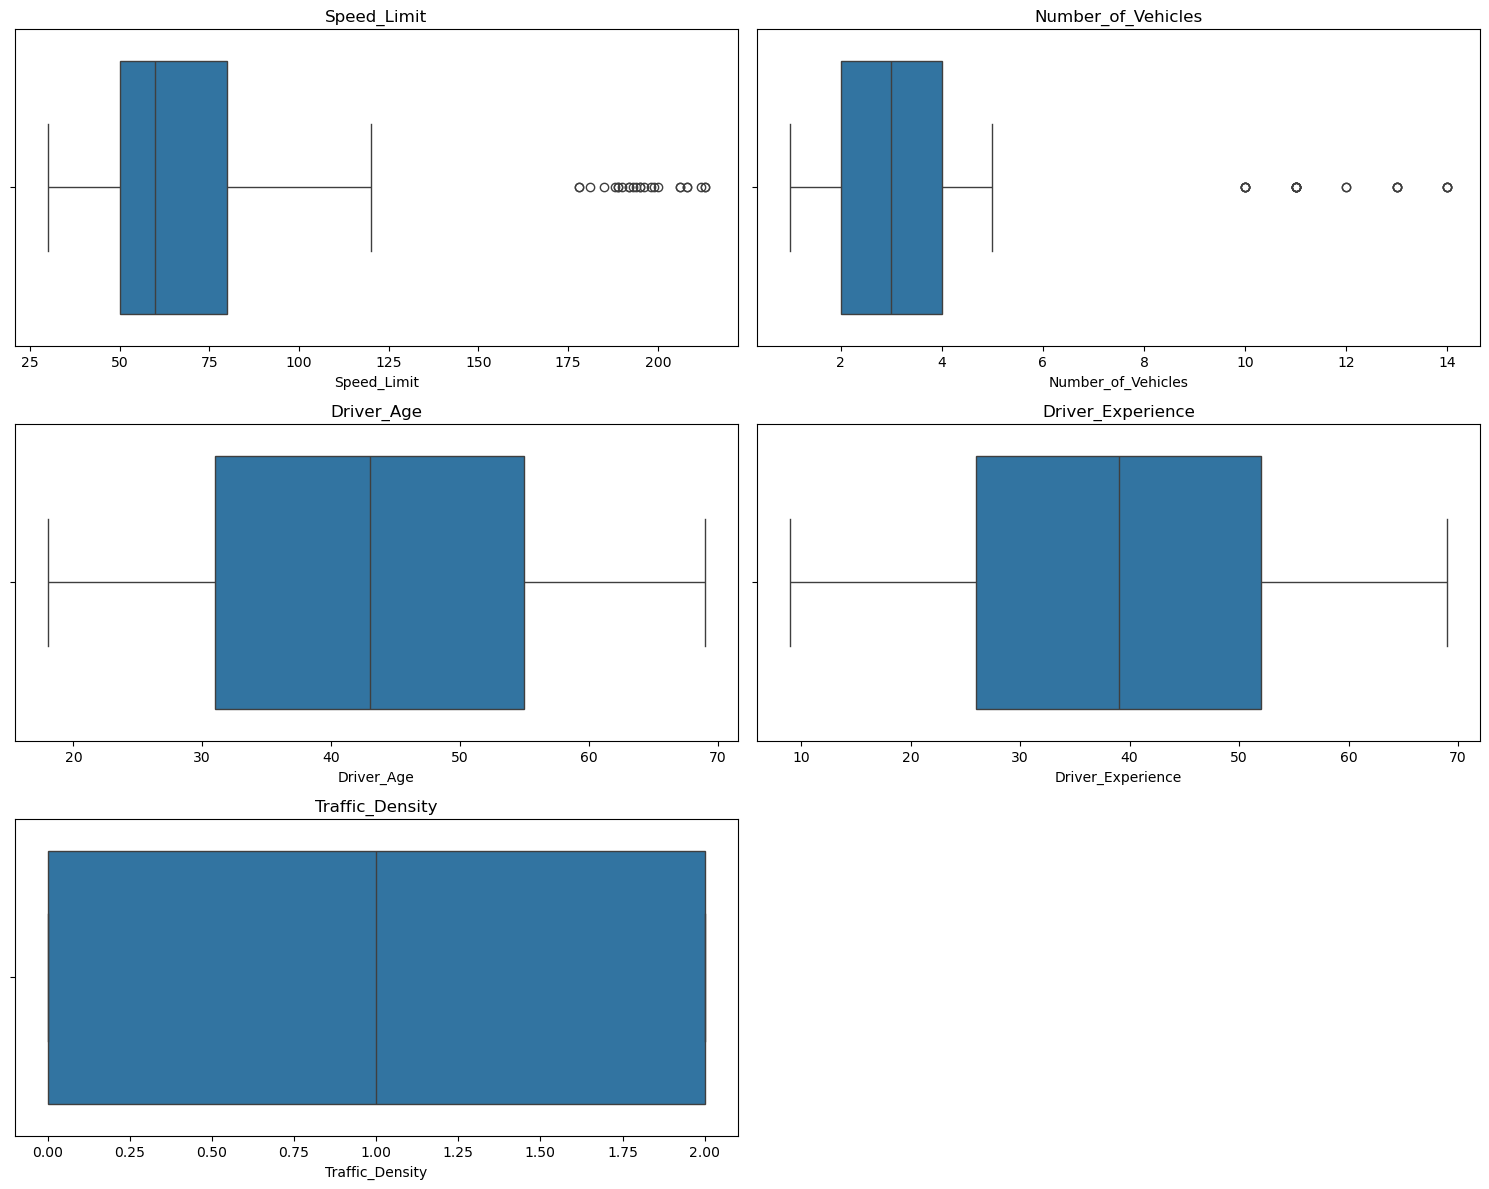

In [19]:
# Creating a grid of subplots with 3 rows and 2 columns, with a specified figure size
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# Creating a boxplot for the 'Speed_Limit' column and placing it in the first subplot
sns.boxplot(x=df['Speed_Limit'], ax=axes[0, 0])
axes[0, 0].set_title('Speed_Limit')  # Setting the title for the subplot

# Creating a boxplot for the 'Number_of_Vehicles' column and placing it in the second subplot
sns.boxplot(x=df['Number_of_Vehicles'], ax=axes[0, 1])
axes[0, 1].set_title('Number_of_Vehicles')  # Setting the title for the subplot

# Creating a boxplot for the 'Driver_Age' column and placing it in the third subplot
sns.boxplot(x=df['Driver_Age'], ax=axes[1, 0])
axes[1, 0].set_title('Driver_Age')  # Setting the title for the subplot

# Creating a boxplot for the 'Driver_Experience' column and placing it in the fourth subplot
sns.boxplot(x=df['Driver_Experience'], ax=axes[1, 1])
axes[1, 1].set_title('Driver_Experience')  # Setting the title for the subplot

# Creating a boxplot for the 'Traffic_Density' column and placing it in the fifth subplot
sns.boxplot(x=df['Traffic_Density'], ax=axes[2, 0])
axes[2, 0].set_title('Traffic_Density')  # Setting the title for the subplot

# Removing the empty subplot (axes[2, 1]) since there are only 5 columns to visualize
fig.delaxes(axes[2, 1])

# Adjusting layout to prevent overlap between subplots
plt.tight_layout()

# Displaying the final plot
plt.show()


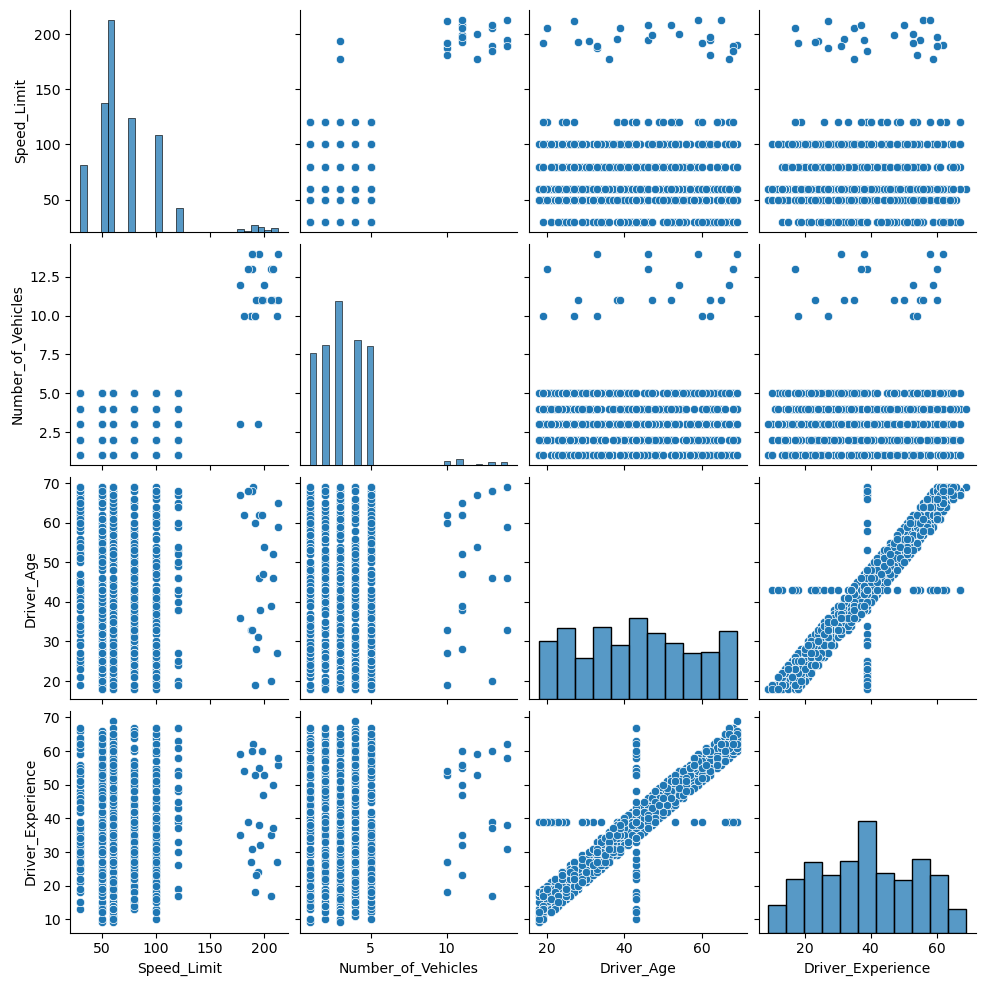

In [20]:
# List of columns to include in the pairplot
cols = ['Speed_Limit', 'Number_of_Vehicles', 'Driver_Age', 'Driver_Experience']

# Creating a pairplot for the selected columns in the DataFrame
sns_plot = sns.pairplot(df[cols])

# Saving the pairplot as an image file named 'pairplot.png'
sns_plot.savefig('pairplot.png')


                    Traffic_Density  Speed_Limit  Number_of_Vehicles  \
Traffic_Density            1.000000    -0.045265           -0.030647   
Speed_Limit               -0.045265     1.000000            0.076297   
Number_of_Vehicles        -0.030647     0.076297            1.000000   
Driver_Alcohol            -0.022652    -0.037757           -0.030421   
Driver_Age                -0.005930    -0.036819           -0.024255   
Driver_Experience         -0.002173    -0.035221           -0.013461   
Accident                  -0.001008    -0.028651            0.036608   

                    Driver_Alcohol  Driver_Age  Driver_Experience  Accident  
Traffic_Density          -0.022652   -0.005930          -0.002173 -0.001008  
Speed_Limit              -0.037757   -0.036819          -0.035221 -0.028651  
Number_of_Vehicles       -0.030421   -0.024255          -0.013461  0.036608  
Driver_Alcohol            1.000000    0.025207           0.026769  0.012788  
Driver_Age                0.02520

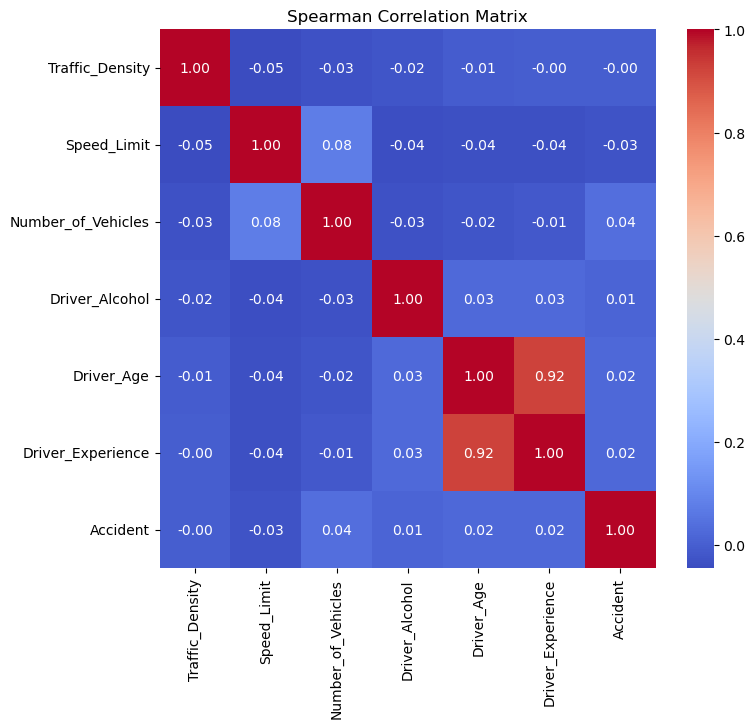

In [21]:
# Selecting only numeric columns from the DataFrame
numeric_df = df.select_dtypes(include=['number'])

# Calculating the Spearman correlation matrix for numeric columns
# Spearman method measures the monotonic relationship between variables
spearman_corr = numeric_df.corr(method='spearman')

# Printing the Spearman correlation matrix to the console
print(spearman_corr)

# Plotting a heatmap to visualize the Spearman correlation matrix
plt.figure(figsize=(8, 7))  # Setting the figure size
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)  # Creating the heatmap
plt.title('Spearman Correlation Matrix')  # Adding a title to the heatmap
plt.show()  # Displaying the heatmap


In [22]:
# Converting categorical columns into dummy variables using one-hot encoding
df = pd.get_dummies(
    df,  # The DataFrame to transform
    columns=['Weather', 'Road_Type', 'Time_of_Day', 'Accident_Severity', 
             'Road_Condition', 'Vehicle_Type', 'Road_Light_Condition'],  # Columns to encode
    drop_first=True  # Dropping the first category to avoid multicollinearity
)


In [23]:
# Creating a new feature 'Age_vs_Experience' by subtracting 'Driver_Experience' from 'Driver_Age'
df['Age_vs_Experience'] = df['Driver_Age'] - df['Driver_Experience']

# Dropping the original 'Driver_Age' and 'Driver_Experience' columns from the DataFrame
df = df.drop(['Driver_Age', 'Driver_Experience'], axis=1)


In [24]:
# Separating the feature set (independent variables) by dropping the target column 'Accident'
X = df.drop(['Accident'], axis=1)

# Assigning the target column 'Accident' as the dependent variable
y = df['Accident']


In [25]:
feature_names = X.columns

In [26]:
# Selecting numeric columns for scaling
numeric_columns = ['Speed_Limit', 'Number_of_Vehicles', 'Age_vs_Experience']

# Initializing the RobustScaler
scaler = RobustScaler()

# Creating a copy of the feature set to preserve the original data
X_scaled = X.copy()

# Scaling the numeric columns using RobustScaler
X_scaled[numeric_columns] = scaler.fit_transform(X[numeric_columns])

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,  # Scaled features
    y,  # Target variable
    test_size=0.33,  # 33% of the data will be used for testing
    random_state=100  # Ensures reproducibility of the split
)


In [27]:
# Initializing the XGBoost Classifier with a default evaluation metric
xgb_classifier = xgb.XGBClassifier(eval_metric='mlogloss')

# Defining the hyperparameter grid for tuning
param_xgb = {
    'n_estimators': [50, 100, 200],       # Number of trees in the forest
    'learning_rate': [0.1, 0.2],          # Step size for updating weights
    'max_depth': [3, 5, 10],              # Maximum depth of each tree
    'subsample': [0.8, 1.0],              # Fraction of samples used for training each tree
    'min_child_weight': [1, 3, 5]         # Minimum sum of instance weights (hessian) needed in a child
}

# Initializing GridSearchCV for hyperparameter tuning
grid_search__xgb = GridSearchCV(
    xgb_classifier,   # The XGBoost classifier instance
    param_xgb,        # The parameter grid
    cv=5              # Number of cross-validation folds
)

# Fitting GridSearchCV to the training data
grid_search__xgb.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             param_grid={'learning_rate': [0.1, 0.2], 'max_depth': [3, 5, 10],
                         'min_child_weight': [1, 3, 5],
                         'n_estimators': [50, 100, 200],
                         'subsample': [0.8, 1.0]})

In [28]:
grid_search__xgb.best_params_

{'learning_rate': 0.1,
 'max_depth': 3,
 'min_child_weight': 5,
 'n_estimators': 50,
 'subsample': 0.8}

In [29]:
best_gs_xgb = grid_search__xgb.best_estimator_

In [30]:
print('Score on train data = ', round(best_gs_xgb.score(X_train, y_train), 4))
print('Score on test data = ', round(best_gs_xgb.score(X_test, y_test), 4))

Score on train data =  0.7382
Score on test data =  0.7206


In [31]:
# Initializing the Random Forest Classifier
rf_classifier = RandomForestClassifier()

# Defining the hyperparameter grid for Random Forest
parametrs_fr = {
    'max_depth': [3, 5, 10],               # Maximum depth of each tree
    'n_estimators': [150, 200, 300],       # Number of trees in the forest
    'min_samples_split': [2, 5, 10],       # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]          # Minimum number of samples required to be at a leaf node
}

# Initializing GridSearchCV for hyperparameter tuning
grid_search_reg_forest3 = GridSearchCV(
    rf_classifier,  # Random Forest Classifier instance
    parametrs_fr,   # Parameter grid
    cv=5            # 5-fold cross-validation
)

# Fitting GridSearchCV to the training data
grid_search_reg_forest3.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [3, 5, 10], 'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [150, 200, 300]})

In [32]:
grid_search_reg_forest3.best_params_

{'max_depth': 5,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 150}

In [42]:
best_gs_knn = grid_search_knn.best_estimator_

In [45]:
print('Score on train data = ', round(best_gs_knn.score(X_train, y_train), 4))
print('Score on test data = ', round(best_gs_knn.score(X_test, y_test), 4))

Score on train data =  0.7127
Score on test data =  0.7132


In [36]:
# Initializing the K-Nearest Neighbors Classifier
knn_classifier = KNeighborsClassifier()

# Defining the hyperparameter grid for KNN
param_knn = {
    'n_neighbors': range(1, 30),          # Number of neighbors to consider
    'weights': ['uniform', 'distance'],  # Weight function used in prediction
    'algorithm': ['auto', 'ball_tree', 'kd_tree'],  # Algorithm to compute nearest neighbors
    'leaf_size': range(10, 50, 5)        # Leaf size for BallTree or KDTree
}

# Initializing GridSearchCV for hyperparameter tuning
grid_search_knn = GridSearchCV(
    knn_classifier,  # KNN Classifier instance
    param_knn,       # Parameter grid
    cv=5             # 5-fold cross-validation
)

# Fitting GridSearchCV to the training data
grid_search_knn.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree'],
                         'leaf_size': range(10, 50, 5),
                         'n_neighbors': range(1, 30),
                         'weights': ['uniform', 'distance']})

In [37]:
grid_search_knn.best_params_

{'algorithm': 'ball_tree',
 'leaf_size': 30,
 'n_neighbors': 28,
 'weights': 'uniform'}

In [38]:
best_gs_knn = grid_search_knn.best_estimator_

In [39]:
print('Score on train data = ', round(best_gs_knn.score(X_train, y_train), 4))
print('Score on test data = ', round(best_gs_knn.score(X_test, y_test), 4))

Score on train data =  0.7127
Score on test data =  0.7132
